<a href="https://colab.research.google.com/github/DilshanBotheju/CSACP_Project/blob/main/HomicidePatternRecognizerDataPreprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Load relevant datasets
homicide_data_path = "/content/drive/MyDrive/DSGP/datasets/database.csv"
homicide_data = pd.read_csv(homicide_data_path, encoding = "latin-1")
homicide_data.head()

<ipython-input-3-acfac49e8cac>:3: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  homicide_data = pd.read_csv(homicide_data_path, encoding = "latin-1")


,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI


In [ ]:
# Identifying shape of the original dataset
homicide_data.shape

(638454, 24)

In [ ]:
# Getting a sample percentage of data to preprocess
sample_percentage = 1
homicide_data = homicide_data.sample(frac=sample_percentage, random_state=42)

In [ ]:
# Identifying shape of sample dataset
homicide_data.shape

(638454, 24)

In [ ]:
# Analyisng crime dataset
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 638454 entries, 484984 to 121958
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Record ID              638454 non-null  int64 
 1   Agency Code            638454 non-null  object
 2   Agency Name            638454 non-null  object
 3   Agency Type            638454 non-null  object
 4   City                   638454 non-null  object
 5   State                  638454 non-null  object
 6   Year                   638454 non-null  int64 
 7   Month                  638454 non-null  object
 8   Incident               638454 non-null  int64 
 9   Crime Type             638454 non-null  object
 10  Crime Solved           638454 non-null  object
 11  Victim Sex             638454 non-null  object
 12  Victim Age             638454 non-null  int64 
 13  Victim Race            638454 non-null  object
 14  Victim Ethnicity       638454 non-null  object
 15  

In [ ]:
# Finding duplicates in dataset
homicide_data.duplicated().sum()

0

In [ ]:
# Replacing unknown with NA to identify null columns
homicide_data.replace("Unknown", np.nan, inplace=True)

In [ ]:
# Identifying null value count
homicide_data.isnull().sum()

,0
Record ID,0
Agency Code,0
Agency Name,47
Agency Type,0
City,0
State,0
Year,0
Month,0
Incident,0
Crime Type,0


In [ ]:
homicide_data.head(20)

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
484984,484985,CA03612,Victorville,Municipal Police,San Bernardino,California,2005,July,1,Murder or Manslaughter,...,Hispanic,NaN,0,NaN,NaN,NaN,Handgun,1,0,FBI
608445,608446,TX10100,Harris County,Sheriff,Harris,Texas,2013,May,3,Murder or Manslaughter,...,Not Hispanic,NaN,0,NaN,NaN,NaN,Firearm,0,0,FBI
417612,417613,AR06200,St. Francis,Sheriff,St. Francis,Arkansas,2001,June,1,Murder or Manslaughter,...,Not Hispanic,Male,18,Black,Not Hispanic,Acquaintance,Handgun,0,0,FBI
372692,372693,AZ01003,Tucson,Municipal Police,Pima,Arizona,1998,March,6,Murder or Manslaughter,...,Not Hispanic,NaN,0,NaN,NaN,NaN,Handgun,0,0,FBI
402028,402029,WA02400,Okanogan,Sheriff,Okanogan,Washington,1999,August,1,Murder or Manslaughter,...,NaN,Male,20,White,NaN,Girlfriend,Rifle,0,0,FBI
541091,541092,MI40502,Kalkaska,Municipal Police,Kalkaska,Michigan,2008,August,1,Murder or Manslaughter,...,NaN,Male,25,White,NaN,NaN,Blunt Object,0,2,FBI
432591,432592,WA03200,Spokane,Sheriff,Spokane,Washington,2001,March,1,Murder or Manslaughter,...,NaN,NaN,0,NaN,NaN,NaN,Handgun,0,0,FBI
489735,489736,MDBPD00,Baltimore,Municipal Police,Baltimore city,Maryland,2005,January,13,Murder or Manslaughter,...,NaN,NaN,0,NaN,NaN,NaN,Handgun,0,0,FBI
630057,630058,LA02800,Lafayette County,Sheriff,Lafayette,Louisiana,2014,February,1,Murder or Manslaughter,...,Not Hispanic,Male,15,Black,Not Hispanic,Husband,Firearm,0,0,FBI
558145,558146,NC03606,Gastonia,Municipal Police,Gaston,North Carolina,2009,April,1,Murder or Manslaughter,...,Not Hispanic,Male,21,Black,Not Hispanic,Stranger,Handgun,0,1,FBI


In [ ]:
# Drop columns with higher null values
homicide_data = homicide_data.drop(["Perpetrator Ethnicity"],axis = 1,errors="ignore")

In [ ]:
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 638454 entries, 484984 to 121958
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Record ID          638454 non-null  int64 
 1   Agency Code        638454 non-null  object
 2   Agency Name        638407 non-null  object
 3   Agency Type        638454 non-null  object
 4   City               638454 non-null  object
 5   State              638454 non-null  object
 6   Year               638454 non-null  int64 
 7   Month              638454 non-null  object
 8   Incident           638454 non-null  int64 
 9   Crime Type         638454 non-null  object
 10  Crime Solved       638454 non-null  object
 11  Victim Sex         637470 non-null  object
 12  Victim Age         638454 non-null  int64 
 13  Victim Race        631778 non-null  object
 14  Victim Ethnicity   270151 non-null  object
 15  Perpetrator Sex    448089 non-null  object
 16  Perpetrator Age    6

In [ ]:
# Handling categorical null values using mode
for column in homicide_data.columns:
    if homicide_data[column].dtype == "object":
        homicide_data[column].fillna(homicide_data[column].mode()[0], inplace=True)

<ipython-input-14-83883757957c>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  homicide_data[column].fillna(homicide_data[column].mode()[0], inplace=True)


In [ ]:
# Handling numerical null values using median
for column in homicide_data.columns:
    if homicide_data[column].dtype != "object":
        homicide_data[column].fillna(homicide_data[column].median(), inplace=True)

<ipython-input-15-a13c21e4658e>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  homicide_data[column].fillna(homicide_data[column].median(), inplace=True)


In [ ]:
# Checking null count
homicide_data.isnull().sum()

,0
Record ID,0
Agency Code,0
Agency Name,0
Agency Type,0
City,0
State,0
Year,0
Month,0
Incident,0
Crime Type,0


In [ ]:
# Viewing updated data
homicide_data.head(10)

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Race,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
484984,484985,CA03612,Victorville,Municipal Police,San Bernardino,California,2005,July,1,Murder or Manslaughter,...,White,Hispanic,Male,0,White,Acquaintance,Handgun,1,0,FBI
608445,608446,TX10100,Harris County,Sheriff,Harris,Texas,2013,May,3,Murder or Manslaughter,...,White,Not Hispanic,Male,0,White,Acquaintance,Firearm,0,0,FBI
417612,417613,AR06200,St. Francis,Sheriff,St. Francis,Arkansas,2001,June,1,Murder or Manslaughter,...,Black,Not Hispanic,Male,18,Black,Acquaintance,Handgun,0,0,FBI
372692,372693,AZ01003,Tucson,Municipal Police,Pima,Arizona,1998,March,6,Murder or Manslaughter,...,White,Not Hispanic,Male,0,White,Acquaintance,Handgun,0,0,FBI
402028,402029,WA02400,Okanogan,Sheriff,Okanogan,Washington,1999,August,1,Murder or Manslaughter,...,White,Not Hispanic,Male,20,White,Girlfriend,Rifle,0,0,FBI
541091,541092,MI40502,Kalkaska,Municipal Police,Kalkaska,Michigan,2008,August,1,Murder or Manslaughter,...,White,Not Hispanic,Male,25,White,Acquaintance,Blunt Object,0,2,FBI
432591,432592,WA03200,Spokane,Sheriff,Spokane,Washington,2001,March,1,Murder or Manslaughter,...,White,Not Hispanic,Male,0,White,Acquaintance,Handgun,0,0,FBI
489735,489736,MDBPD00,Baltimore,Municipal Police,Baltimore city,Maryland,2005,January,13,Murder or Manslaughter,...,Black,Not Hispanic,Male,0,White,Acquaintance,Handgun,0,0,FBI
630057,630058,LA02800,Lafayette County,Sheriff,Lafayette,Louisiana,2014,February,1,Murder or Manslaughter,...,White,Not Hispanic,Male,15,Black,Husband,Firearm,0,0,FBI
558145,558146,NC03606,Gastonia,Municipal Police,Gaston,North Carolina,2009,April,1,Murder or Manslaughter,...,Black,Not Hispanic,Male,21,Black,Stranger,Handgun,0,1,FBI


In [ ]:
# Convert Month to datetime format
homicide_data["Month"] = pd.to_datetime(homicide_data["Month"], format="%B", errors="coerce").dt.month

In [ ]:
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 638454 entries, 484984 to 121958
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Record ID          638454 non-null  int64 
 1   Agency Code        638454 non-null  object
 2   Agency Name        638454 non-null  object
 3   Agency Type        638454 non-null  object
 4   City               638454 non-null  object
 5   State              638454 non-null  object
 6   Year               638454 non-null  int64 
 7   Month              638454 non-null  int32 
 8   Incident           638454 non-null  int64 
 9   Crime Type         638454 non-null  object
 10  Crime Solved       638454 non-null  object
 11  Victim Sex         638454 non-null  object
 12  Victim Age         638454 non-null  int64 
 13  Victim Race        638454 non-null  object
 14  Victim Ethnicity   638454 non-null  object
 15  Perpetrator Sex    638454 non-null  object
 16  Perpetrator Age    6

In [ ]:
# Drop non-essential columns
homicide_data = homicide_data.drop(columns=["Record ID", "Record Source","Agency Code","Agency Name","Agency Type","Crime Solved", "Victim Ethnicity"],axis=1,errors="ignore")



In [ ]:
# Viewing remaining dataset
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 638454 entries, 484984 to 121958
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   City               638454 non-null  object
 1   State              638454 non-null  object
 2   Year               638454 non-null  int64 
 3   Month              638454 non-null  int32 
 4   Incident           638454 non-null  int64 
 5   Crime Type         638454 non-null  object
 6   Victim Sex         638454 non-null  object
 7   Victim Age         638454 non-null  int64 
 8   Victim Race        638454 non-null  object
 9   Perpetrator Sex    638454 non-null  object
 10  Perpetrator Age    638454 non-null  object
 11  Perpetrator Race   638454 non-null  object
 12  Relationship       638454 non-null  object
 13  Weapon             638454 non-null  object
 14  Victim Count       638454 non-null  int64 
 15  Perpetrator Count  638454 non-null  int64 
dtypes: int32(1), int64(5

Preprocess with columns

In [ ]:
# Getting categories for victim sex
homicide_data["Victim Sex"].value_counts()

,count
Victim Sex,
Male,495109
Female,143345


In [ ]:
# Getting categories for victim age
homicide_data["Victim Age"].value_counts()

,count
Victim Age,
22,23049
20,23031
25,22939
21,22796
23,22438
...,...
94,116
95,82
97,39


<ipython-input-24-ee40fb6b4a9f>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Victim Age Group", order=homicide_data["Victim Age Group"].value_counts().index, palette="viridis")


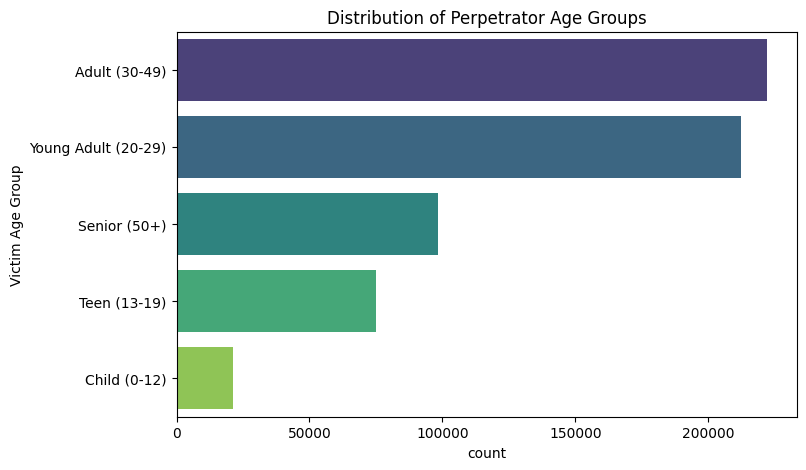

In [ ]:
# Converting Perpetrator age to numeric
homicide_data["Victim Age"] = pd.to_numeric(homicide_data["Victim Age"], errors="coerce")

# Define age bins and labels
age_bins = [0, 12, 19, 29, 49, 100]
age_labels = ["Child (0-12)", "Teen (13-19)", "Young Adult (20-29)", "Adult (30-49)", "Senior (50+)"]

# Create new column with age categories
homicide_data["Victim Age Group"] = pd.cut(homicide_data["Victim Age"], bins=age_bins, labels=age_labels, right=True)

# Display the distribution of age groups
plt.figure(figsize=(8, 5))
sns.countplot(data=homicide_data, y="Victim Age Group", order=homicide_data["Victim Age Group"].value_counts().index, palette="viridis")
plt.title("Distribution of Perpetrator Age Groups")
plt.show()


In [ ]:
# Getting categories for perprator age groups
homicide_data["Perpetrator Age"].value_counts()

,count
Perpetrator Age,
0,211079
20,21158
19,19807
21,18509
18,18477
...,...
,1
6,1
92,1


<ipython-input-26-36eb510e9211>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Perpetrator Age Group", order=homicide_data["Perpetrator Age Group"].value_counts().index, palette="viridis")


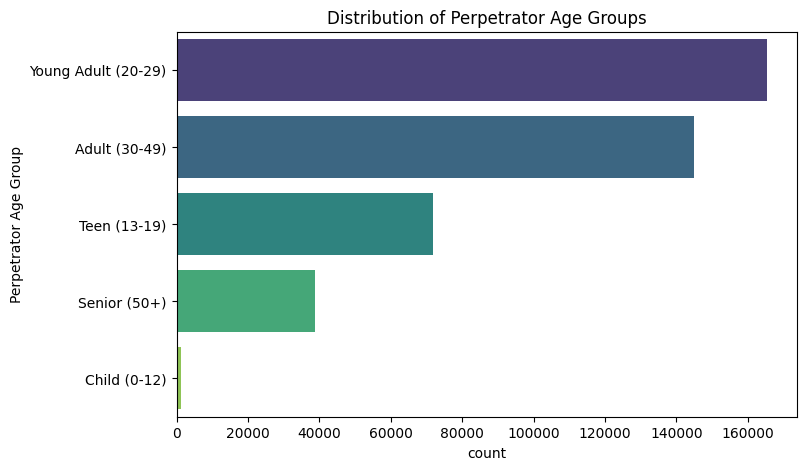

In [ ]:
# Converting Perpetrator age to numeric
homicide_data["Perpetrator Age"] = pd.to_numeric(homicide_data["Perpetrator Age"], errors="coerce")

# Define age bins and labels
age_bins = [0, 12, 19, 29, 49, 100]
age_labels = ["Child (0-12)", "Teen (13-19)", "Young Adult (20-29)", "Adult (30-49)", "Senior (50+)"]

# Create new column with age categories
homicide_data["Perpetrator Age Group"] = pd.cut(homicide_data["Perpetrator Age"], bins=age_bins, labels=age_labels, right=True)

# Display the distribution of age groups
plt.figure(figsize=(8, 5))
sns.countplot(data=homicide_data, y="Perpetrator Age Group", order=homicide_data["Perpetrator Age Group"].value_counts().index, palette="viridis")
plt.title("Distribution of Perpetrator Age Groups")
plt.show()


In [ ]:
# Getting categories for relationship
homicide_data["Relationship"].value_counts()

,count
Relationship,
Acquaintance,399031
Stranger,96593
Wife,23187
Friend,21945
Girlfriend,16465
Son,9904
Family,9535
Husband,8803
Daughter,7539


In [ ]:
# Getting categories for weapons
homicide_data["Weapon"].value_counts()

,count
Weapon,
Handgun,350676
Knife,94962
Blunt Object,67337
Firearm,46980
Shotgun,30722
Rifle,23347
Strangulation,8110
Fire,6173
Suffocation,3968


In [ ]:
# Getting categories for victim count
homicide_data["Victim Count"].value_counts()

,count
Victim Count,
0,586059
1,38750
2,8156
3,2847
4,1084
5,510
9,290
6,286
7,168


In [ ]:
# Getting categories for perpetrator count
homicide_data["Perpetrator Count"].value_counts()

,count
Perpetrator Count,
0,558838
1,54745
2,15777
3,6531
4,1489
5,592
6,207
7,129
8,52


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/DSGP/datasets/preprocessed_dataset.csv'

homicide_data.to_csv(file_path, index=False)
print(f"File saved to {file_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File saved to /content/drive/My Drive/DSGP/datasets/preprocessed_dataset.csv
